Loading data...
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


C:\Users\HP\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Training model...
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9139 - loss: 0.2945 - val_accuracy: 0.9578 - val_loss: 0.1381
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9577 - loss: 0.1434 - val_accuracy: 0.9690 - val_loss: 0.1013
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9684 - loss: 0.1053 - val_accuracy: 0.9727 - val_loss: 0.0854
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9724 - loss: 0.0893 - val_accuracy: 0.9773 - val_loss: 0.0765
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9758 - loss: 0.0750 - val_accuracy: 0.9791 - val_loss: 0.0706
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


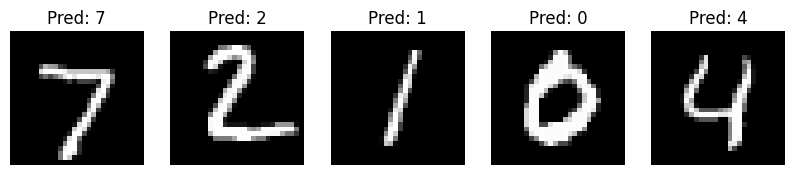

Final Accuracy: 97.58%


In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

# 1. Load the MNIST dataset (Built-in)
print("Loading data...")
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# 2. Preprocess: Scale pixels to a range of 0 to 1
x_train, x_test = x_train / 255.0, x_test / 255.0

# 3. Build the Artificial Neural Network (ANN)
model = models.Sequential([
    layers.Flatten(input_shape=(28, 28)),    # Convert 2D image to 1D vector
    layers.Dense(128, activation='relu'),    # Hidden layer with 128 neurons
    layers.Dropout(0.2),                     # Prevents overfitting
    layers.Dense(10, activation='softmax')   # Output layer for digits 0-9
])

# 4. Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 5. Train the model
print("Training model...")
history = model.fit(x_train, y_train, epochs=5, validation_data=(x_test, y_test))

# 6. Evaluate and Visualize Predictions
predictions = model.predict(x_test)

plt.figure(figsize=(10,4))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(x_test[i], cmap='gray')
    plt.title(f"Pred: {np.argmax(predictions[i])}")
    plt.axis('off')

# Save the plot for GitHub
plt.savefig('digit_recognition_sample.png')
plt.show()

print(f"Final Accuracy: {history.history['accuracy'][-1]*100:.2f}%")